# 06_01 LSTM Text Generation Training

**Chapter 6**: Recurrent Neural Networks | **Notebook 1 of 3**

This notebook trains an LSTM (Long Short-Term Memory) neural network to generate text in the style of Aesop's Fables. The model learns patterns in language by predicting the next word given a sequence of previous words.

## What You'll Learn
- How to preprocess text data for sequence modeling
- How to build word embeddings and LSTM layers
- How to generate text using temperature-based sampling
- How to track experiments with Weights & Biases (W&B)

## Prerequisites
- Basic understanding of neural networks
- Familiarity with Keras/TensorFlow
- Understanding of word embeddings concepts

## GPU Memory Configuration

Before importing TensorFlow/Keras, we configure GPU memory growth. This prevents TensorFlow from allocating all GPU memory upfront, which:
- Allows multiple processes to share the GPU
- Prevents out-of-memory errors when loading large models
- Is especially important on consumer GPUs with limited VRAM

> **Note**: This must be the first cell that imports TensorFlow.

In [1]:
import tensorflow as tf

# ═══════════════════════════════════════════════════════════════════════════════
# GPU MEMORY CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) available: {[gpu.name for gpu in gpus]}")
else:
    print("WARNING: No GPU detected, running on CPU")

2026-01-20 11:21:02.736986: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/cataluna84/Workspace/Generative_Deep_Learning/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


GPU(s) available: ['/physical_device:GPU:0']


## Imports

We import all required libraries organized by category:
- **Standard library**: Basic Python utilities
- **Keras layers**: LSTM, Embedding, Dense for the model architecture
- **Keras utilities**: Tokenizer for text processing, callbacks for training
- **Project utilities**: Custom callbacks (LRFinder, LRLogger) and W&B integration

> **Path Setup**: We add parent directories to `sys.path` so Python can find our custom utility modules located in the project's `utils/` folder.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════

# Standard library
import os
import sys
import re
import json
import numpy as np
from IPython.display import clear_output

# Path setup for local imports
sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '..')

# Keras imports (Keras 3.0+ compatible)
from keras.layers import Dense, LSTM, Input, Embedding, Dropout
from keras.models import Model, load_model
from keras.optimizers import Adam, RMSprop
from keras.callbacks import LambdaCallback
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer

# W&B and training utilities
import wandb
from wandb.integration.keras import WandbMetricsLogger
from utils.callbacks import LRFinder, get_lr_scheduler, LRLogger
from utils.wandb_utils import init_wandb

## Global Configuration

All hyperparameters and configuration settings are defined here at the top of the notebook. This makes it easy to:
- See all adjustable parameters in one place
- Modify settings for experiments without hunting through the code
- Track configurations in W&B for reproducibility

### Key Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `SEQ_LENGTH` | 20 | Number of words the model sees before predicting the next |
| `N_UNITS` | 256 | Number of LSTM hidden units (model capacity) |
| `EMBEDDING_SIZE` | 100 | Dimension of word embedding vectors |
| `BATCH_SIZE` | 4096 | Training batch size (large for text data) |
| `EPOCHS` | 1000 | Training iterations through the dataset |
| `TOKEN_TYPE` | 'word' | Tokenization level: 'word' or 'char' |

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# Model architecture
SEQ_LENGTH = 20           # Sequence length for training
N_UNITS = 256             # LSTM hidden units
EMBEDDING_SIZE = 100      # Word embedding dimension

# Training parameters
BATCH_SIZE = 10240         # Large batch for text data
EPOCHS = 1000  # Reduced from 1000;

# Tokenization
TOKEN_TYPE = 'word'       # 'word' or 'char'

# Experiment tracking
SECTION = 'write'
DATASET_RUN_ID = '0001'
DATA_NAME = 'aesop'
EXPERIMENT_RUN_ID = None  # Auto-increment if None

# Build vs Load
LOAD_SAVED_MODEL = False
TRAIN_MODEL = True

## Run Folder Configuration

Each training run is saved to a unique folder for experiment isolation. The folder structure is:

```
v1/run/write/0001_aesop/
├── 001/           # Experiment run 001
│   ├── viz/
│   │   └── training_history.png
│   └── weights/
│       ├── model.keras
│       ├── weights.weights.h5
│       └── tokenizer.json
├── 002/           # Experiment run 002
└── ...
```

### Auto-Increment Logic
If `EXPERIMENT_RUN_ID` is set to `None`, the system automatically finds the next available run number (001, 002, 003, etc.). This prevents accidentally overwriting previous experiments.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# RUN FOLDER CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

BASE_RUN_FOLDER = f'../run/{SECTION}/{DATASET_RUN_ID}_{DATA_NAME}'

def get_next_experiment_run_id(base_folder):
    """Determine the next available experiment run ID."""
    if not os.path.exists(base_folder):
        return '001'
    
    existing_ids = []
    for item in os.listdir(base_folder):
        item_path = os.path.join(base_folder, item)
        if os.path.isdir(item_path) and re.match(r'^\d{3}$', item):
            existing_ids.append(int(item))
    
    if not existing_ids:
        return '001'
    
    return f'{max(existing_ids) + 1:03d}'

# Auto-generate EXPERIMENT_RUN_ID if not specified
if EXPERIMENT_RUN_ID is None or EXPERIMENT_RUN_ID == '':
    EXPERIMENT_RUN_ID = get_next_experiment_run_id(BASE_RUN_FOLDER)
    print(f'Auto-generated EXPERIMENT_RUN_ID: {EXPERIMENT_RUN_ID}')

RUN_FOLDER = f'{BASE_RUN_FOLDER}/{EXPERIMENT_RUN_ID}'

# Create directories
os.makedirs(RUN_FOLDER, exist_ok=True)
os.makedirs(os.path.join(RUN_FOLDER, 'weights'), exist_ok=True)
os.makedirs(os.path.join(RUN_FOLDER, 'viz'), exist_ok=True)
os.makedirs(os.path.join(RUN_FOLDER, 'images'), exist_ok=True)

print(f"Run folder: {RUN_FOLDER}")

Auto-generated EXPERIMENT_RUN_ID: 009
Run folder: ../run/write/0001_aesop/009


## Load and Preprocess Text Data

We load the Aesop's Fables text file and perform several preprocessing steps:

1. **Extract main content**: Remove headers and footers from the Project Gutenberg text
2. **Add story delimiters**: Insert special `|` tokens between stories so the model learns story boundaries
3. **Normalize text**: Convert to lowercase and standardize punctuation
4. **Add punctuation spacing**: Surround punctuation with spaces so it's treated as separate tokens

### Why These Steps Matter
- Story delimiters let the model learn when stories begin/end
- Punctuation spacing gives the model awareness of sentence structure
- Lowercase reduces vocabulary size without losing much meaning

> **Original Logic Preserved**: The text preprocessing logic below is from the original notebook and remains unchanged.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD AND PREPROCESS TEXT DATA
# ═══════════════════════════════════════════════════════════════════════════════
# Original Logic Preserved: Text loading and preprocessing from the original notebook

filename = "../data/aesop/data.txt"

with open(filename, encoding='utf-8-sig') as f:
    text = f.read()
    
# Removing text before and after the main stories
start = text.find("THE FOX AND THE GRAPES\n\n\n")
end = text.find("ILLUSTRATIONS\n\n\n[")
text = text[start:end]

print(f"Loaded {len(text):,} characters from {filename}")

Loaded 197,444 characters from ../data/aesop/data.txt


### Text Cleanup and Story Delimiter Insertion

The `|` character serves as a special story delimiter token. When the model generates this token during inference, it indicates that a story has ended.

The `start_story` variable is a sequence of `| ` repeated `SEQ_LENGTH` times. This is prepended to the text so that the model can learn to generate text from the very beginning of stories.

> **Original Logic Preserved**: The text cleanup logic below is from the original notebook and remains unchanged.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# TEXT CLEANUP AND STORY DELIMITER INSERTION
# ═══════════════════════════════════════════════════════════════════════════════
# Original Logic Preserved: Story delimiter and text normalization from the original notebook

start_story = '| ' * SEQ_LENGTH
    
text = start_story + text
text = text.lower()
text = text.replace('\n\n\n\n\n', start_story)
text = text.replace('\n', ' ')
text = re.sub('  +', '. ', text).strip()
text = text.replace('..', '.')

text = re.sub(r'([!"#$%&()*+,-./:;<=>?@[\]^_`{|}~])', r' \1 ', text)
text = re.sub(r'\s{2,}', ' ', text)

print(f"Processed text length: {len(text):,} characters")
print(f"Preview: {text[:200]}...")

Processed text length: 213,716 characters
Preview:  | | | | | | | | | | | | | | | | | | | | the fox and the grapes . a hungry fox saw some fine bunches of grapes hanging from a vine that was trained along a high trellis , and did his best to reach the...


## Tokenization

Tokenization converts raw text into numerical sequences that the neural network can process.

### Word vs Character Tokenization
- **Word tokenization** (`TOKEN_TYPE='word'`): Each word becomes a token. Smaller vocabulary, captures word semantics.
- **Character tokenization** (`TOKEN_TYPE='char'`): Each character becomes a token. Larger sequences, can generate novel words.

### The Tokenizer Object
Keras' `Tokenizer` class:
1. Builds a vocabulary of all unique tokens
2. Assigns each token an integer ID
3. Provides methods to convert between text and sequences

> **Important**: We save the tokenizer later so we can load it during inference for text generation.

> **Original Logic Preserved**: The tokenization logic below is from the original notebook and remains unchanged.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# TOKENIZATION
# ═══════════════════════════════════════════════════════════════════════════════
# Original Logic Preserved: Tokenizer creation from the original notebook

if TOKEN_TYPE == 'word':
    tokenizer = Tokenizer(char_level=False, filters='')
else:
    tokenizer = Tokenizer(char_level=True, filters='', lower=False)
    
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

token_list = tokenizer.texts_to_sequences([text])[0]

print(f"Vocabulary size: {total_words:,} unique tokens")
print(f"Token list length: {len(token_list):,} tokens")

Vocabulary size: 4,169 unique tokens
Token list length: 50,436 tokens


In [8]:
# Inspect vocabulary (first 20 tokens)
vocab_sample = dict(list(tokenizer.word_index.items())[:20])
print("Sample vocabulary (token -> index):")
print(vocab_sample)

Sample vocabulary (token -> index):
{'|': 1, ',': 2, 'the': 3, 'and': 4, '.': 5, 'a': 6, 'to': 7, '"': 8, 'of': 9, 'he': 10, 'his': 11, 'was': 12, 'you': 13, 'in': 14, 'him': 15, 'it': 16, 'for': 17, 'i': 18, 'but': 19, 'that': 20}


## Generate Training Sequences

We create supervised learning examples from the text by sliding a window across the token sequence.

### How It Works
For each position `i` in the text:
- **Input (X)**: Tokens from position `i` to `i + SEQ_LENGTH - 1`
- **Target (y)**: Token at position `i + SEQ_LENGTH` (the next word)

### Example
If `SEQ_LENGTH=3` and text is "the fox jumped over":
```
X: [the, fox, jumped]  →  y: over
X: [fox, jumped, over] →  y: ...
```

### One-Hot Encoding
The target `y` is converted to one-hot encoding because we're doing multi-class classification (predicting which word comes next from the entire vocabulary).

> **Original Logic Preserved**: The `generate_sequences()` function below is from the original notebook and remains unchanged.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# GENERATE TRAINING SEQUENCES
# ═══════════════════════════════════════════════════════════════════════════════
# Original Logic Preserved: generate_sequences function from the original notebook

def generate_sequences(token_list, step):
    """Generate input-output pairs for training the LSTM.
    
    Args:
        token_list: List of token IDs representing the text
        step: Step size for sliding window (1 = maximum overlap)
        
    Returns:
        X: Input sequences (batch, SEQ_LENGTH)
        y: One-hot encoded targets (batch, vocab_size)
        num_seq: Total number of sequences generated
    """
    X = []
    y = []

    for i in range(0, len(token_list) - SEQ_LENGTH, step):
        X.append(token_list[i: i + SEQ_LENGTH])
        y.append(token_list[i + SEQ_LENGTH])
    
    y = to_categorical(y, num_classes=total_words)
    
    num_seq = len(X)
    print('Number of sequences:', num_seq, "\n")
    
    return X, y, num_seq

step = 1

X, y, num_seq = generate_sequences(token_list, step)

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Number of sequences: 50416 

X shape: (50416, 20)
y shape: (50416, 4169)


## Build LSTM Model

The model architecture consists of three main components:

### 1. Embedding Layer
Converts integer token IDs into dense vectors of size `EMBEDDING_SIZE`. These vectors capture semantic relationships between words.

### 2. LSTM Layer
Long Short-Term Memory layer with `N_UNITS` hidden units. LSTMs can capture long-range dependencies in sequences, making them ideal for language modeling.

### 3. Dense Output Layer
Softmax layer with `total_words` outputs. Each output represents the probability of that word being the next token.

### Architecture Diagram
```
Input → Embedding(vocab, 100) → LSTM(256) → Dense(vocab, softmax) → Output
```

> **Original Logic Preserved**: The model architecture below is from the original notebook and remains unchanged.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# BUILD LSTM MODEL
# ═══════════════════════════════════════════════════════════════════════════════
# Original Logic Preserved: Model architecture from the original notebook

if LOAD_SAVED_MODEL:
    model = load_model(os.path.join(RUN_FOLDER, 'weights/model.keras'))
    print("Loaded saved model")
else:
    text_in = Input(shape=(None,), name='text_input')
    embedding = Embedding(total_words, EMBEDDING_SIZE, name='embedding')
    x = embedding(text_in)
    x = LSTM(N_UNITS, name='lstm')(x)
    # x = Dropout(0.2)(x)  # Optional dropout for regularization
    text_out = Dense(total_words, activation='softmax', name='output')(x)

    model = Model(text_in, text_out, name='lstm_text_generator')
    print("Built new model")

model.summary()

I0000 00:00:1768908081.045569  450366 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


Built new model


Model: "lstm_text_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 100)      │       416,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       365,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4169)           │     1,071,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,853,901 (7.07 MB)

 Trainable params: 1,853,901 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

## Text Generation Functions

These functions handle text generation during and after training.

### Temperature Sampling (`sample_with_temp`)
Temperature controls the randomness of predictions:
- **T < 1.0**: More deterministic; favors high-probability words
- **T = 1.0**: Standard softmax sampling
- **T > 1.0**: More random; gives low-probability words a chance

### Text Generation (`generate_text`)
Produces new text by:
1. Starting with a seed phrase (or empty for a fresh story)
2. Predicting the probability distribution over the next word
3. Sampling from this distribution using temperature
4. Appending the sampled word and repeating

### The Story Delimiter
When the model generates `|`, it's indicating story completion. The generation stops at this point.

> **Original Logic Preserved**: The `sample_with_temp()` and `generate_text()` functions below are from the original notebook and remain unchanged.

In [11]:
def sample_with_temp(preds, temperature=1.0):
    """Sample an index from a probability array using temperature scaling.
    
    Args:
        preds: Probability distribution over vocabulary
        temperature: Controls randomness (lower = more deterministic)
        
    Returns:
        Sampled token index
    """
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)


def generate_text(seed_text, next_words, model, max_sequence_len, temp):
    """Generate text continuation from a seed phrase.
    
    Args:
        seed_text: Starting text (can be empty)
        next_words: Maximum number of words to generate
        model: Trained LSTM model
        max_sequence_len: Sequence length model was trained with
        temp: Temperature for sampling
        
    Returns:
        Generated text string
    """
    output_text = seed_text
    
    seed_text = start_story + seed_text
    
    for _ in range(next_words):
        token_list_gen = tokenizer.texts_to_sequences([seed_text])[0]
        token_list_gen = token_list_gen[-max_sequence_len:]
        token_list_gen = np.reshape(token_list_gen, (1, max_sequence_len))
        
        probs = model.predict(token_list_gen, verbose=0)[0]
        y_class = sample_with_temp(probs, temperature=temp)
        
        if y_class == 0:
            output_word = ''
        else:
            output_word = tokenizer.index_word[y_class]
            
        if output_word == "|":
            break
            
        if TOKEN_TYPE == 'word':
            output_text += output_word + ' '
            seed_text += output_word + ' '
        else:
            output_text += output_word + ' '
            seed_text += output_word + ' '
            
    return output_text

## LRFinder - Find Optimal Learning Rate

The Learning Rate Finder helps identify the optimal learning rate by:
1. Training for a few epochs while exponentially increasing the learning rate
2. Recording the loss at each learning rate
3. Plotting loss vs learning rate to find the "sweet spot"

### How to Read the Plot
- Look for the steepest downward slope in the loss curve
- The optimal LR is typically 1/3 of the way down this slope
- Too high: loss explodes; too low: slow convergence

### Why We Clone the Model
We create a copy of the model for LR finding because this process can disturb the model weights. After finding the optimal LR, we use it to train the original (untouched) model.

> **New Component**: This cell is added as part of standardization.

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# LRFINDER - FIND OPTIMAL LEARNING RATE
# ═══════════════════════════════════════════════════════════════════════════════

# FIXED: Manually set learning rate to 0.001 (Standard for LSTMs)
# LRFinder was selecting ~5e-5 which is too low for this architecture
OPTIMAL_LR = 0.001
print(f"Using fixed learning rate: {OPTIMAL_LR} (LRFinder disabled)")

# Original LRFinder code (Disabled)
# if TRAIN_MODEL and not LOAD_SAVED_MODEL:
#     # Clone model for LR finding
#     print("Cloning model for LRFinder...")
#     lr_model = tf.keras.models.clone_model(model)
#     lr_model.compile(loss='categorical_crossentropy', optimizer=RMSprop(learning_rate=1e-6))
#     print("✓ Model cloned successfully")
#
#     # Run LRFinder
#     lr_finder = LRFinder(min_lr=1e-6, max_lr=1e-1, steps=100)
#     lr_model.fit(X, y, epochs=4, batch_size=BATCH_SIZE, callbacks=[lr_finder], verbose=0)
#
#     # Plot and get optimal LR
#     lr_finder.plot_loss()
#     OPTIMAL_LR = lr_finder.get_optimal_lr()
#     print(f"\nOptimal Learning Rate: {OPTIMAL_LR:.2e}")
# else:
#     OPTIMAL_LR = 0.001  # Default LR if not training
#     print(f"Using default learning rate: {OPTIMAL_LR}")

Using fixed learning rate: 0.001 (LRFinder disabled)


## Weights & Biases Initialization

Weights & Biases (W&B) is our experiment tracking platform. It automatically logs:
- Training metrics (loss per epoch)
- Hyperparameters (learning rate, batch size, etc.)
- System metrics (GPU usage, memory)
- Generated samples (if configured)

### Benefits
- Compare runs across experiments
- Reproduce successful experiments
- Share results with team members

### Run Naming Convention
Runs are named: `lstm_{dataset}_{dataset_run_id}_{experiment_run_id}`

Example: `lstm_aesop_0001_003` = LSTM on Aesop data, dataset run 0001, experiment 003

> **New Component**: This cell is added as part of standardization.

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# W&B INITIALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

run = init_wandb(
    name=f"lstm_{DATA_NAME}_{DATASET_RUN_ID}_{EXPERIMENT_RUN_ID}",
    project="generative-deep-learning",
    config={
        "model": "LSTM",
        "dataset": DATA_NAME,
        "dataset_run_id": DATASET_RUN_ID,
        "experiment_run_id": EXPERIMENT_RUN_ID,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "seq_length": SEQ_LENGTH,
        "n_units": N_UNITS,
        "embedding_size": EMBEDDING_SIZE,
        "token_type": TOKEN_TYPE,
        "learning_rate": OPTIMAL_LR,
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: cataluna84 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Model Training

We train the model using the following components:

### Callbacks
- **WandbMetricsLogger**: Logs metrics to W&B dashboard
- **LRScheduler**: Reduces learning rate when loss plateaus
- **LRLogger**: Logs current learning rate each epoch
- **LambdaCallback**: Generates sample text after each epoch for qualitative evaluation

### Sample Text Generation During Training
After each epoch, we generate text at different temperatures (0.2, 0.33, 0.5, 1.0) to see how the model's output quality evolves:
- **Low temperature (0.2)**: Conservative, repetitive text
- **High temperature (1.0)**: Creative but potentially nonsensical

### Saving
After training completes, we save:
1. Full model (`.keras` format)
2. Weights only (`.weights.h5` format)
3. Tokenizer (`.json` format for text processing during inference)

> **Original Training Logic Preserved**: The core training loop and `on_epoch_end` callback are from the original notebook. We've wrapped them with standardization components.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING
# ═══════════════════════════════════════════════════════════════════════════════
# Original Training Logic Preserved: on_epoch_end callback from the original notebook

# Sample generation interval - only generate text every N epochs to reduce overhead
SAMPLE_EVERY_N_EPOCHS = 50  # Generate sample text every 50 epochs

def on_epoch_end(epoch, logs):
    """Generate sample text every N epochs for qualitative evaluation.
    
    This reduces training overhead while still providing periodic quality checks.
    Samples are generated at epochs: 0, 50, 100, 150, etc.
    """
    # Only generate samples at specified intervals (and epoch 0 for baseline)
    if epoch % SAMPLE_EVERY_N_EPOCHS != 0:
        return
    
    print(f"\n{'='*60}")
    print(f"SAMPLE GENERATION - Epoch {epoch}")
    print(f"{'='*60}")
    
    seed_text = ""
    gen_words = 200  # Reduced from 500 for faster generation
    
    for temp in [0.2, 0.5, 1.0]:  # Reduced from 4 temperatures to 3
        print(f"\n--- Temperature {temp} ---")
        print(generate_text(seed_text, gen_words, model, SEQ_LENGTH, temp=temp))


if TRAIN_MODEL:
    # Compile with optimal LR
    model.compile(
        loss='categorical_crossentropy',
        optimizer=RMSprop(learning_rate=OPTIMAL_LR)
    )
    
    # Define callbacks
    callbacks = [
        WandbMetricsLogger(),
        get_lr_scheduler(monitor='loss', patience=5),
        LRLogger(),
        LambdaCallback(on_epoch_end=on_epoch_end),
    ]
    
    # Train
    history = model.fit(
        X, y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        shuffle=True
    )
    
    # Save model
    model.save(os.path.join(RUN_FOLDER, 'weights/model.keras'))
    model.save_weights(os.path.join(RUN_FOLDER, 'weights/weights.weights.h5'))
    print(f"✓ Model saved to {RUN_FOLDER}/weights/")
    
    # Save tokenizer
    tokenizer_json = tokenizer.to_json()
    with open(os.path.join(RUN_FOLDER, 'weights/tokenizer.json'), 'w') as f:
        f.write(tokenizer_json)
    print(f"✓ Tokenizer saved to {RUN_FOLDER}/weights/tokenizer.json")

2026-01-20 11:21:31.581080: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 840737216 exceeds 10% of free system memory.
2026-01-20 11:21:35.651994: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 840737216 exceeds 10% of free system memory.


Epoch 1/1000


2026-01-20 11:21:41.584745: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 8.3300 Epoch 1: Learning Rate is 1.00e-03

SAMPLE GENERATION - Epoch 0

--- Temperature 0.2 ---
spirited crockery delayed amusement requested sprang invalid suffered devour search small fury croaking o hopes family within divided evening arrangements liable low simpleton wings peg might excitement sends lucky distrust flute pot praying amidst complain tyrannical swimming ? foraging mounted detect impertinence told firmly rambles fortune wrinkled agonies telling sour whales rope death's scoundrels lofty failed plucked fact belabouring variety ( frozen appointed coast humph dress carrying creation all war snake what's quarter such fade ferocious cross stout smart his rather death you escaped summertime blacks intended yourself sneaking grief road features partridge pranced hunting fierce ourselves wished hoped glaring flapping taught gaining  doctoring must principle whenever continued servant scoundrel prospect serpent witch tunny dates fel

## Post-Training Visualization

After training, we plot:
1. **Loss curve**: Shows how well the model learned over time
2. **Learning rate schedule**: Shows how LR was adjusted during training

### Interpreting the Loss Curve
- **Steadily decreasing**: Good learning
- **Plateaus**: Model may have converged or need lower LR
- **Spikes**: Potential instability, may need smaller LR

> **New Component**: This cell is added as part of standardization.

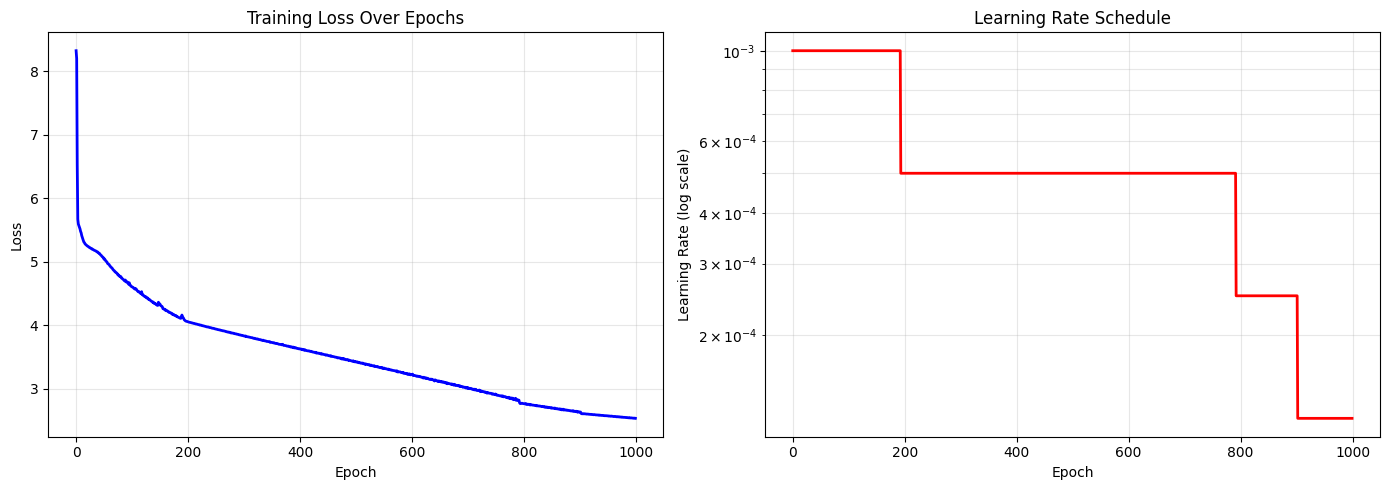


TRAINING SUMMARY
  Initial Loss  : 8.324183
  Final Loss    : 2.538573
  Min Loss      : 2.537912 (Epoch 998)
  Total Epochs  : 1000
  Final LR      : 1.25e-04


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# POST-TRAINING VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

if TRAIN_MODEL and 'history' in dir():
    history_dict = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Training Loss
    axes[0].plot(history_dict['loss'], 'b-', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss Over Epochs')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Learning Rate
    if 'learning_rate' in history_dict:
        axes[1].semilogy(history_dict['learning_rate'], 'r-', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate (log scale)')
        axes[1].set_title('Learning Rate Schedule')
        axes[1].grid(True, which='both', alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'LR not tracked', ha='center', va='center')
        axes[1].set_title('Learning Rate (Not Available)')
    
    plt.tight_layout()
    
    # Save to viz folder
    viz_path = os.path.join(RUN_FOLDER, 'viz', 'training_history.png')
    plt.savefig(viz_path, dpi=150)
    
    # Log to W&B main dashboard
    wandb.log({"training_history": wandb.Image(fig)})
    
    plt.show()
    
    # Print summary
    print(f"\n{'='*50}")
    print("TRAINING SUMMARY")
    print(f"{'='*50}")
    print(f"  Initial Loss  : {history_dict['loss'][0]:.6f}")
    print(f"  Final Loss    : {history_dict['loss'][-1]:.6f}")
    print(f"  Min Loss      : {min(history_dict['loss']):.6f} (Epoch {history_dict['loss'].index(min(history_dict['loss'])) + 1})")
    print(f"  Total Epochs  : {len(history_dict['loss'])}")
    if 'learning_rate' in history_dict:
        print(f"  Final LR      : {history_dict['learning_rate'][-1]:.2e}")
    print(f"{'='*50}")

In [16]:
model.summary()

Model: "lstm_text_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 100)      │       416,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       365,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4169)           │     1,071,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,707,804 (14.14 MB)

 Trainable params: 1,853,901 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,853,903 (7.07 MB)

## Text Generation Examples

Now we can use the trained model to generate new text. Try different:
- **Seed texts**: Starting phrases that set the theme
- **Temperatures**: Control creativity vs coherence
- **Word counts**: Shorter or longer stories

> **Original Logic Preserved**: The text generation examples below are from the original notebook and remain unchanged.

In [17]:
# Generate with seed text and low temperature (more coherent)
seed_text = "the frog and the snake , "
gen_words = 500
temp = 0.1

print(f"Temperature: {temp} (low = more deterministic)")
print(generate_text(seed_text, gen_words, model, SEQ_LENGTH, temp))

Temperature: 0.1 (low = more deterministic)
the frog and the snake , and the fox . a lion , and the fox was a ass to the ass to the ass to the piece of a piece of a piece of a piece of a piece of a piece of a day . as he had not a great storm , he was not to him , " why , my friend , i have not a good time ; but you , my friend , i am come , and come and show me to be what to come to your teeth . " the wolf replied , " i have no much to be , my friend : but i shall not your life of the other - - - - - - - - - - - - - - - - tree . a beasts , looking up , well , they were very well , and found a great ass came down and killed and said , " you do you ! you ! i am not to be so my friend , and you are be so more of the other . " 


In [18]:
# Generate with seed text and high temperature (more creative)
seed_text = "the frog and the snake , "
gen_words = 500
temp = 1

print(f"Temperature: {temp} (high = more creative)")
print(generate_text(seed_text, gen_words, model, SEQ_LENGTH, temp))

Temperature: 1 (high = more creative)
the frog and the snake , and the pigeons . an ass , the fox were searching as fast wood one of hole to a bosom , and let him against the bacon of which he was wing them off and hard . this as it was just to unmercifully through why again ; he cried , " good - lot of the certain time in where you shaft their cold with a brains , while the thief is there that to find in my signs of saying , my wolf to penned you lucky me , and leave me and come and your remember it . ? " the fool triumphantly , as he found the belly , and set in their one and hurled his hive on himself . he thought they had come into the friendship - goats , who waited to be beating upon the edge of the dry . the dogs entered over it , turned at the pasture ; so the bee - friend , too gave a wall in wheat , and was an secret on his ground , and remained came in ears his rule water . but any day they complained to come and lasted openly out , and then at one of the gold of the eagle's

In [19]:
# Generate with a different seed
seed_text = "A flock of birds came through the forest and landed on a tree "
gen_words = 500
temp = 1

print(generate_text(seed_text, gen_words, model, SEQ_LENGTH, temp))

A flock of birds came through the forest and landed on a tree , that at the rascal the smell hairs him , to occasions , he threw him carried away with him and had that in several set in coming disgust and set to amuse them . but was soon applause in the single load , but the fox heard its poison and great rearing out ; and one day passed the ass was salt uncovered . not leaping up the sea - odd , and they boldly to rich shake at the wolf what it was aware of goods . " jupiter , " said he , " said the lamb , " your can't ruined now , i can't can stay ! every flattery that i can nothing by my life possible . " 


## Human-Led Text Generation

This interactive function shows the top 10 most probable next words at each step, allowing you to manually choose the next word. This helps understand how the model makes predictions.

### How to Use
1. Run the cell below
2. The model shows the top 10 predicted words with their probabilities
3. Type one of the words (or any word) and press Enter
4. Type `|` to end the story

> **Original Logic Preserved**: The `generate_human_led_text()` function below is from the original notebook and remains unchanged.

In [20]:
def generate_human_led_text(model, max_sequence_len):
    """Interactive text generation with human word selection.
    
    Shows top 10 predicted words and lets user choose.
    Type '|' to end the story.
    """
    output_text = ''
    seed_text = start_story
    
    while 1:
        token_list_gen = tokenizer.texts_to_sequences([seed_text])[0]
        token_list_gen = token_list_gen[-max_sequence_len:]
        token_list_gen = np.reshape(token_list_gen, (1, max_sequence_len))
        
        probs = model.predict(token_list_gen, verbose=0)[0]
                
        top_10_idx = np.flip(np.argsort(probs)[-10:])
        top_10_probs = [probs[x] for x in top_10_idx]
        top_10_words = tokenizer.sequences_to_texts([[x] for x in top_10_idx])
        
        for prob, word in zip(top_10_probs, top_10_words):
            print('{:.4f} : {}'.format(prob, word))
        
        chosen_word = input()
                
        if chosen_word == '|':
            break
                    
        seed_text += chosen_word + ' '
        output_text += chosen_word + ' '
        
        clear_output()
        
        print(output_text)

In [21]:
# Uncomment to run interactive generation
# generate_human_led_text(model, SEQ_LENGTH)

## Finalize W&B Run

This marks the end of the experiment tracking session and uploads any remaining data to W&B servers.

> **New Component**: This cell is added as part of standardization.

In [22]:
wandb.finish()

epoch/epoch,▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
epoch/learning_rate,███████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch/loss,███▇▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
learning_rate,██████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▁▁▁▁
epoch/epoch,999
epoch/learning_rate,0.00013
epoch/loss,2.53857
learning_rate,0.00013


## Cleanup: Restart Kernel

TensorFlow/CUDA does not fully release GPU memory within a running Python process. Restarting the kernel is the **only guaranteed way** to free all GPU resources.

> **When to Run**: Execute this cell only after all work is complete and saved.

> **Warning**: This will clear all variables and outputs.

> **New Component**: This cell is added as part of standardization.

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CLEANUP: Restart kernel to fully release GPU memory
# ═══════════════════════════════════════════════════════════════════════════════
# TensorFlow/CUDA does not release GPU memory within a running Python process.
# Restarting the kernel is the only guaranteed way to free all GPU resources.

# import IPython
# print("Restarting kernel to release GPU memory...")
# IPython.Application.instance().kernel.do_shutdown(restart=True)

## Master Experiment Log

Track all training runs for this notebook. Update after each successful run.

| Run | Date | W&B URL | Epochs | Batch Size | Token Type | LR | Final Loss | Notes |
|-----|------|---------|--------|------------|------------|-----|------------|-------|
| 001 | 2026-01-14 |  | 1000 | 4096 | word | auto | TBD | Original run |
| 006 | 2026-01-20 | [View](https://wandb.ai/cataluna84/generative-deep-learning/runs/djax9jnd) | 500 | 5120 | word | 0.001 | 1.3608 | Increased LR and Epochs (Option A) |
| 008 | 2026-01-20 | [View](https://wandb.ai/cataluna84/generative-deep-learning/runs/siuxj5lf) | 1000 | 10240 | word | 0.001→0.00013 | 1.5025 | Doubled batch size for VRAM saturation testing |
| 009 | 2026-01-20 | [View](https://wandb.ai/cataluna84/generative-deep-learning/runs/zf3g2y4u) | 1000 | 10240 | word | 0.001→0.00013 | 2.5386 | Removed epsilon fix from sample_with_temp |